# Tracer test

This code presents a synthetic tracer test example where we consider a two-pulse tracer injection of equal mass in the well, separated by a time delay.
We measure the concentration of the tracer in an observation piezometer and we want aim to identify the porosity and dispersivity of the aquifer.
This hydrogeological example shows how traditionnal metrics can lead to non-convex objective functions and how optimal transport distances can improve that.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Optimal_transport as OT


def Gradient(x0,f,h=1e-2):
    
    '''
    Approximate the Gradient vector of f at x0 using finite differences, knowing the value of f at every point of the domain

    x0: n-vecteur containing the parameter value at which the hessian should be evaluated

    f: Function that return a value for a list of parameter x


    '''

    dim=f.__code__.co_argcount
    Gradient=np.zeros((dim))    
    for i in range(dim):
            Gradient[i]= (f(*(x0+np.array([h/2 if k == i else 0 for k in range(dim)])))
                        -f(*(x0-np.array([h/2 if k == i else 0 for k in range(dim)]))))/h
      
    return Gradient


def steepest_descent(X0,f,num_iter_max=100,eps=1e-3,Xmin=[0,0],Xmax=[1,1],eta=1e-3,h=1e-2):
    """
    Compute the steepest descent algorithm
    
    Parameters
    ----------
    
    X0: array, starting position
    f: function to be minimised 
    num_iter_max: int, maximum number of iteration
    eps: float, precision for the final result
    Xmin: array, minimum bounds
    Xmax: array, maximum bounds
    eta: float, learning rate
    h: float, gradient evaluation precision
    
    
    Returns
    -------
    
    X: Final position
    Err: list of all errors from X0 to X
    Xs: list of all positions from X0 to X
    
    """
    
    dim=f.__code__.co_argcount

    X=X0
    Xs=[X0]
    Err=[]
    for i in range(num_iter_max):
        
        if all(list(map(lambda x,y,z : x>=y and x<=z, X,Xmin,Xmax))):
            Err.append(f(*X))
            
            dk=-1*eta*Gradient(X,f,h)
            if np.sum(abs(dk))<=eps:
                print('Descent finished')
                break
            X=X+dk
            Xs.append(X)
        else:
            Err.append(f(*X))
            print('X got out of bound')
            break
        if i==num_iter_max-1:
            print('Maximum number of iteration reached')
    return np.array(X),np.array(Err),np.array(Xs)

    
    
# Analytical solution of Welty (1994)



def diverging(t,alpha,R,Q,Phi,L,M=1,rho=1000):
        
    """
    Compute the Concentration of a tracer in a well in diverging radial flow a single injection according to Welty 1994
    
    Parameters
    ----------
    
    t: float, time at which the concentration is observed
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    float, concentration in the well at t
    
    """
    
    tc=t/(R**2 *np.pi*Phi*L/Q)
    e=-1*(1-tc)**2/((16*alpha*tc**1.5)/(3*R))
    denom=np.sqrt(tc**1.5)
    c_norm=np.nan_to_num(np.exp(e)/denom)
    return c_norm*M/(rho*2*np.pi*Phi*L*(R**2)*np.sqrt(4*np.pi*alpha/(3*R)))


def multipeaks(times,t_start,alpha,R,Q,Phi,L,M=1,rho=1000): 
    """
    Compute the Concentration of a tracer in a well in diverging radial flow with multiple injections according to Welty 1994
    
    Parameters
    ----------
    
    times: List or numpy Array, contains the time steps
    t_start: List or numpy Array, contains the starting times of all the injections
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    List or numpy Array, contains the concentration in the well for every time steps of t
    
    """
    
    res=np.zeros(len(times))
    for k in range(len(t_start)):
        t=times-t_start[k]
        res[t>0]+=diverging(t[t>0],alpha,R,Q,Phi,L,M=M,rho=rho)
    return res


def f_Sinkhorn(alpha_n,phi_n):
    """
    Objective fonction using Sinkhorn distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, Sinkhorn error
    
    """
    
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_target,times,cs,Sinkhorn_dist=True,reg=1,logeps=5,NumIterMax=200,k1=.2,k2=1)/np.max(cs_target)


def f_WD(alpha_n,phi_n):

    """
    Objective fonction using Wasserstein distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, Wasserstein distance error
    
    """
    
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_target,times,cs,reg=1)/np.max(cs_target) #np.log?

def f_L2(alpha_n,phi_n):
    """
    Objective fonction using L2 distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, L2 error
    
    """
    
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return np.sum(((cs-cs_target)/np.max(cs_target))**2) 


alpha_target=1
phi_target=0.15

seconds_in_day=3600*24
times=np.linspace(100,seconds_in_day*300,300)
cs_target=multipeaks(times,[0,20*seconds_in_day],alpha=alpha_target,R=220,Q=10000/1000/60,Phi=phi_target,L=20)



The gradient descent are computed on the normalised dispersivity and porosity, and using either L2, Wasserstein or Sinkhorn based objective functions

## Gradient descent using L2 norm

In [2]:
i=20
j=20


phi0=i/99
alpha0=j/99

XfinL2,ErrL2,XsL2=steepest_descent([alpha0,phi0],f_L2,num_iter_max=10000,eps=1e-6,Xmin=[0,0],Xmax=[1,1],eta=5e-6)

np.savetxt(f'arrays_gradient/XsL2_{i}_{j}.txt',XsL2)
np.savetxt(f'arrays_gradient/ErrL2_{i}_{j}.txt',ErrL2)

X got out of bound


## Gradient descent using WD norm

In [3]:
i=20
j=20


phi0=i/99
alpha0=j/99

XfinW,ErrW,XsW=steepest_descent([alpha0,phi0],f_WD,num_iter_max=10000,eps=1e-6,Xmin=[0,0],Xmax=[1,1],eta=1e-1)
np.savetxt(f'arrays_gradient/XsW_{i}_{j}.txt',XsW)
np.savetxt(f'arrays_gradient/ErrW_{i}_{j}.txt',ErrW)



Descent finished


## Gradient descent using Sinkhorn Norm

The steepest gradient descent in that case is quite slow to reach the optimum because of not steep gradient at the center and
another grandient method (with increasing steps for example) would be better. It was used here for the sake of making figures 
showing the direction of the gradient descent but is not to be used as an optimisation algorithm.

i=20
j=20


phi0=i/99
alpha0=j/99

XfinS,ErrS,XsS=steepest_descent([alpha0,phi0],f_Sinkhorn,num_iter_max=1000,eps=1e-7,Xmin=[0,0],Xmax=[1,1],eta=7e-2)

np.savetxt(f'arrays_gradient/XsS_{i}_{j}.txt',XsS)
np.savetxt(f'arrays_gradient/ErrS_{i}_{j}.txt',ErrS)


In [4]:
def add_arrow(line, position=None, direction='right', size=15, color=None):
    """
    add an arrow to a line.

    line:       Line2D object
    position:   x-position of the arrow. If None, mean of xdata is taken
    direction:  'left' or 'right'
    size:       size of the arrow in fontsize points
    color:      if None, line color is taken.
    """
    if color is None:
        color = line.get_color()

    xdata = line.get_xdata()
    ydata = line.get_ydata()

    if position is None:
        position = xdata.mean()
    # find closest index
    start_ind = np.argmin(np.absolute(xdata - position))
    if direction == 'right':
        end_ind = start_ind + 1
    else:
        end_ind = start_ind - 1

    line.axes.annotate('',
        xytext=(xdata[start_ind], ydata[start_ind]),
        xy=(xdata[end_ind], ydata[end_ind]),
        arrowprops=dict(arrowstyle="->", color=color),
        size=size,zorder=4
    )

# Figures

All the gradient descents and objective function evaluation have been precomputed and stored in the folder "arrays_gradient". The following cells show the figures.

In [5]:
from matplotlib.colors import LinearSegmentedColormap

ncolors=100
A=plt.cm.get_cmap('Greys')(range(ncolors))
A[:,-1]=np.linspace(0,.3,100)
map_object = LinearSegmentedColormap.from_list(name='transparent_greys',colors=A)

C:\Users\rycvo\AppData\Local\Temp\ipykernel_46580\1441923605.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  A=plt.cm.get_cmap('Greys')(range(ncolors))


In [6]:
X_L2=np.loadtxt('arrays_gradient/xresL2.txt')
Y_L2=np.loadtxt('arrays_gradient/yresL2.txt')

alphas=np.logspace(-1,1,100)
phis=np.logspace(-1.3,-0.3,100)

Err_L2=np.loadtxt('arrays_gradient/l2.txt')
Err_Ot_W=np.loadtxt('arrays_gradient/otw.txt')
Err_Ot_S4=np.loadtxt('arrays_gradient/ots_eps4.txt')
Err_Ot_S5=np.loadtxt('arrays_gradient/ots_eps5.txt')
Err_Ot_S6=np.loadtxt('arrays_gradient/ots.txt')

alpha_target=1
phi_target=0.15

X_target=[np.log10(alpha_target)/2+.5,np.log10(phi_target)+1.3]

y_alphas,x_phis=np.meshgrid(alphas,phis,indexing='xy')

In [7]:
Xs_L2_20_20=np.loadtxt('arrays_gradient/XsL2_20_20.txt')
Err_L2_20_20=np.loadtxt('arrays_gradient/ErrL2_20_20.txt')

Xs_W_20_20=np.loadtxt('arrays_gradient/XsW_20_20.txt')
Err_W_20_20=np.loadtxt('arrays_gradient/ErrW_20_20.txt')

Xs_S_20_20=np.loadtxt('arrays_gradient/XsS_20_20.txt')
Err_S_20_20=np.loadtxt('arrays_gradient/ErrS_20_20.txt')


Xs_L2_60_30=np.loadtxt('arrays_gradient/XsL2_60_30.txt')
Err_L2_60_30=np.loadtxt('arrays_gradient/ErrL2_60_30.txt')

Xs_W_60_30=np.loadtxt('arrays_gradient/XsW_60_30.txt')
Err_W_60_30=np.loadtxt('arrays_gradient/ErrW_60_30.txt')

Xs_S_60_30=np.loadtxt('arrays_gradient/XsS_60_30.txt')
Err_S_60_30=np.loadtxt('arrays_gradient/ErrS_60_30.txt')

Xs_L2_30_30=np.loadtxt('arrays_gradient/XsL2_30_30.txt')
Err_L2_30_30=np.loadtxt('arrays_gradient/ErrL2_30_30.txt')

Xs_W_30_30=np.loadtxt('arrays_gradient/XsW_30_30.txt')
Err_W_30_30=np.loadtxt('arrays_gradient/ErrW_30_30.txt')

Xs_S_30_30=np.loadtxt('arrays_gradient/XsS_30_30.txt')
Err_S_30_30=np.loadtxt('arrays_gradient/ErrS_30_30.txt')

Xs_L2_80_10=np.loadtxt('arrays_gradient/XsL2_80_10.txt')
Err_L2_80_10=np.loadtxt('arrays_gradient/ErrL2_80_10.txt')

Xs_W_80_10=np.loadtxt('arrays_gradient/XsW_80_10.txt')
Err_W_80_10=np.loadtxt('arrays_gradient/ErrW_80_10.txt')

Xs_S_80_10=np.loadtxt('arrays_gradient/XsS_80_10.txt')
Err_S_80_10=np.loadtxt('arrays_gradient/ErrS_80_10.txt')


In [8]:
def plot_trajectories(i,j,Xs,ax,in_bounds=True,posa=50):
    phi0=i/99
    alpha0=j/99
    ax.plot(10**(phi0-1.3),10**(alpha0*2-1),'>',color='green',markersize=10,label='starting point')
    line=ax.plot(10**(Xs[:,1]-1.3),10**(Xs[:,0]*2-1),color='black',linewidth=1,zorder=3)
    pos_arrow=10**(Xs[posa,1]-1.3)
    add_arrow(line[0],position=pos_arrow)
    if in_bounds:
        ax.plot(10**(Xs[-1][1]-1.3),10**(Xs[-1][0]*2-1),'o',color='red',markersize=10,label='ending point')

In [9]:
times=np.linspace(0,1,1000)
cs_target=np.loadtxt('arrays_gradient/cs_target.txt')
cs_04_1=np.loadtxt('arrays_gradient/cs_04_1.txt')
cs_05_05=np.loadtxt('arrays_gradient/cs_05_05.txt')
cs_065_05=np.loadtxt('arrays_gradient/cs_065_05.txt')

## Objective function maps

The following figures show maps of the objective functions and gradient descent traajectories

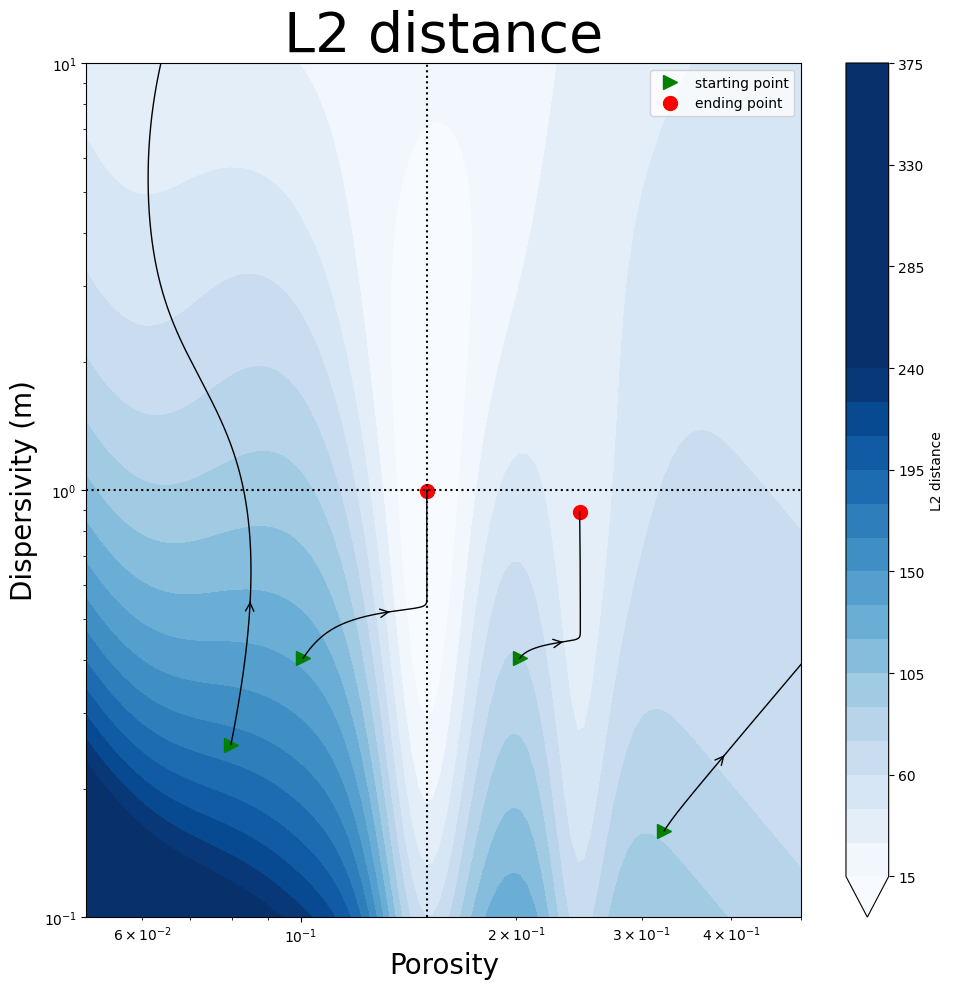

In [10]:
plt.figure(figsize=(10,10))
ax=plt.gca()

plt.contourf(x_phis,y_alphas,Err_L2,cmap='Blues',levels=30,extend='min',vmax=240)
cbar=plt.colorbar(label='L2 distance')

plt.title('L2 distance', fontsize=40)
plt.plot([phis[0],phis[-1]],[alpha_target,alpha_target],color='black',linestyle='dotted',zorder=4)
plt.plot([phi_target,phi_target],[alphas[0],alphas[-1]],color='black',linestyle='dotted',zorder=4)

plot_trajectories(20,20,Xs_L2_20_20,ax,in_bounds=False,posa=400)
plot_trajectories(60,30,Xs_L2_60_30,ax,posa=30)
plot_trajectories(30,30,Xs_L2_30_30,ax)
plot_trajectories(80,10,Xs_L2_80_10,ax,in_bounds=False,posa=200)

plt.xlim(np.min(x_phis),np.max(x_phis))
plt.ylim(np.min(y_alphas),np.max(y_alphas))
plt.xlabel('Porosity', fontsize=20)
plt.ylabel('Dispersivity (m)', fontsize=20)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())



ax = plt.gca()
ax.set_yscale('log')
ax.set_xscale('log')

plt.tight_layout()

#plt.savefig('Figures/1_L2_distance.png',dpi=300)

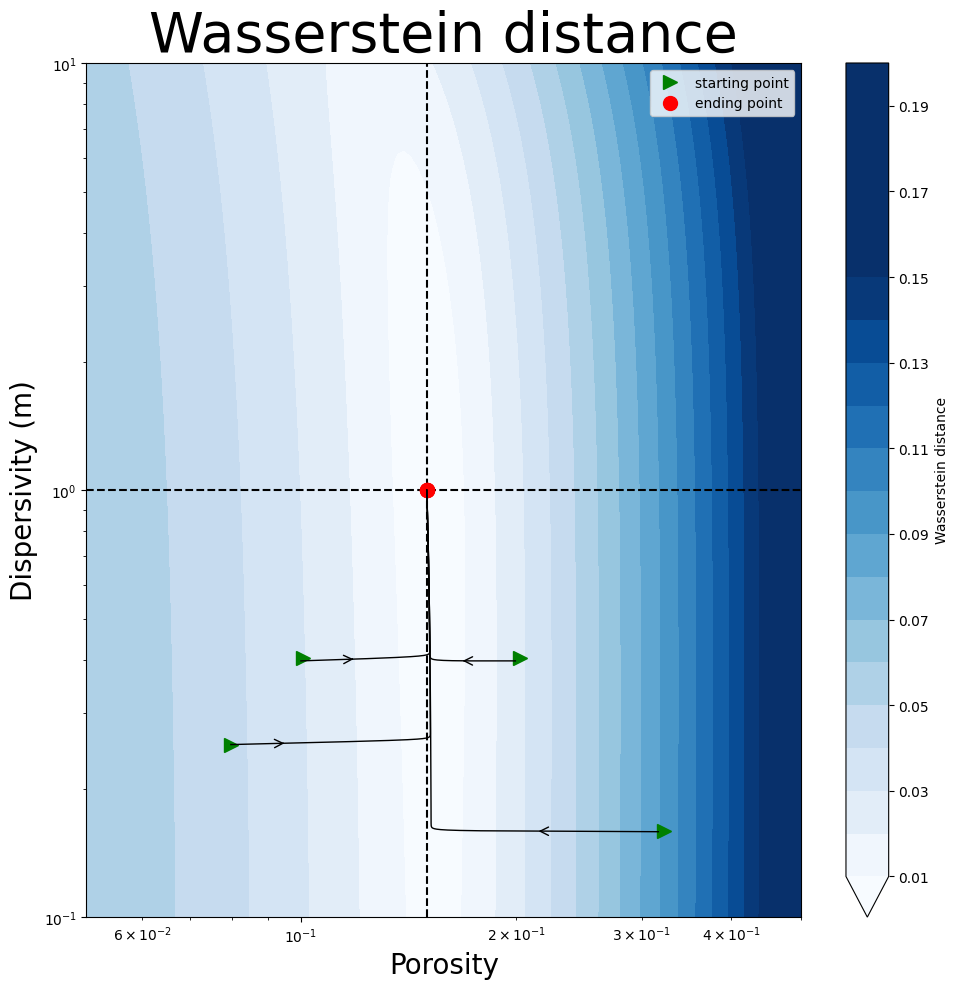

In [11]:
plt.figure(figsize=(10,10))
ax=plt.gca()
plt.contourf(x_phis,y_alphas,Err_Ot_W,cmap='Blues',levels=20,extend='min',alpha=1,vmax=.15)
cbar=plt.colorbar(label='Wasserstein distance')

plt.title('Wasserstein distance', fontsize=40)
plt.plot([phis[0],phis[-1]],[alpha_target,alpha_target],color='black',linestyle='dashed')
plt.plot([phi_target,phi_target],[alphas[0],alphas[-1]],color='black',linestyle='dashed')


plot_trajectories(20,20,Xs_W_20_20,ax)
plot_trajectories(60,30,Xs_W_60_30,ax,posa=30)
plot_trajectories(30,30,Xs_W_30_30,ax)
plot_trajectories(80,10,Xs_W_80_10,ax)

plt.xlim(np.min(x_phis),np.max(x_phis))
plt.ylim(np.min(y_alphas),np.max(y_alphas))
plt.xlabel('Porosity', fontsize=20)
plt.ylabel('Dispersivity (m)', fontsize=20)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())



ax = plt.gca()
ax.set_yscale('log')
ax.set_xscale('log')

plt.tight_layout()

#plt.savefig('Figures/1_W_distance.png',dpi=300)

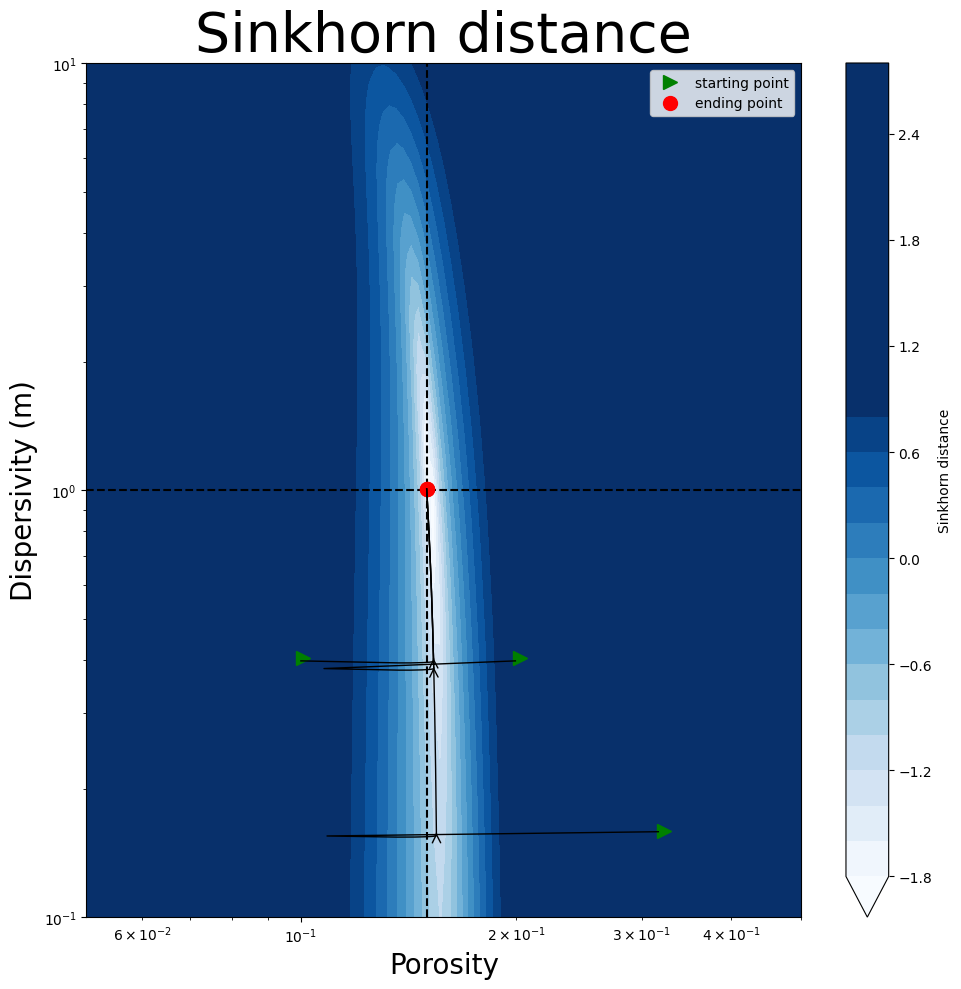

In [12]:
plt.figure(figsize=(10,10))
ax = plt.gca()

plt.contourf(x_phis,y_alphas,np.log10(Err_Ot_S5),cmap='Blues',levels=30,extend='min',vmax=.9)
cbar=plt.colorbar(label='Sinkhorn distance')

plt.title('Sinkhorn distance', fontsize=40)
plt.plot([phis[0],phis[-1]],[alpha_target,alpha_target],color='black',linestyle='dashed')
plt.plot([phi_target,phi_target],[alphas[0],alphas[-1]],color='black',linestyle='dashed')


plot_trajectories(60,30,Xs_S_60_30,ax,posa=30)
plot_trajectories(30,30,Xs_S_30_30,ax)
plot_trajectories(80,10,Xs_S_80_10,ax)

plt.xlabel('Porosity', fontsize=20)
plt.ylabel('Dispersivity (m)', fontsize=20)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())


ax.set_yscale('log')
ax.set_xscale('log')

plt.tight_layout()

#plt.savefig('Figures/3_S_distance.png',dpi=300)

In [13]:
def plot_trajectories3d(i,j,Xs,Err,ax,in_bounds=True,mark=(3, 0,60)):
    phi0=i/99
    alpha0=j/99
    ax.plot(phi0-1.3,alpha0*2-1,zs=Err[0],marker=mark,color='green',label='starting point',zorder=4)
    line=ax.plot(Xs[:,1]-1.3,Xs[:,0]*2-1,zs=Err,color='black',zorder=4)
    if in_bounds:
        ax.plot(Xs[-1][1]-1.3,Xs[-1][0]*2-1,zs=Err[-1],marker='o',color='red',label='ending point',zorder=4)

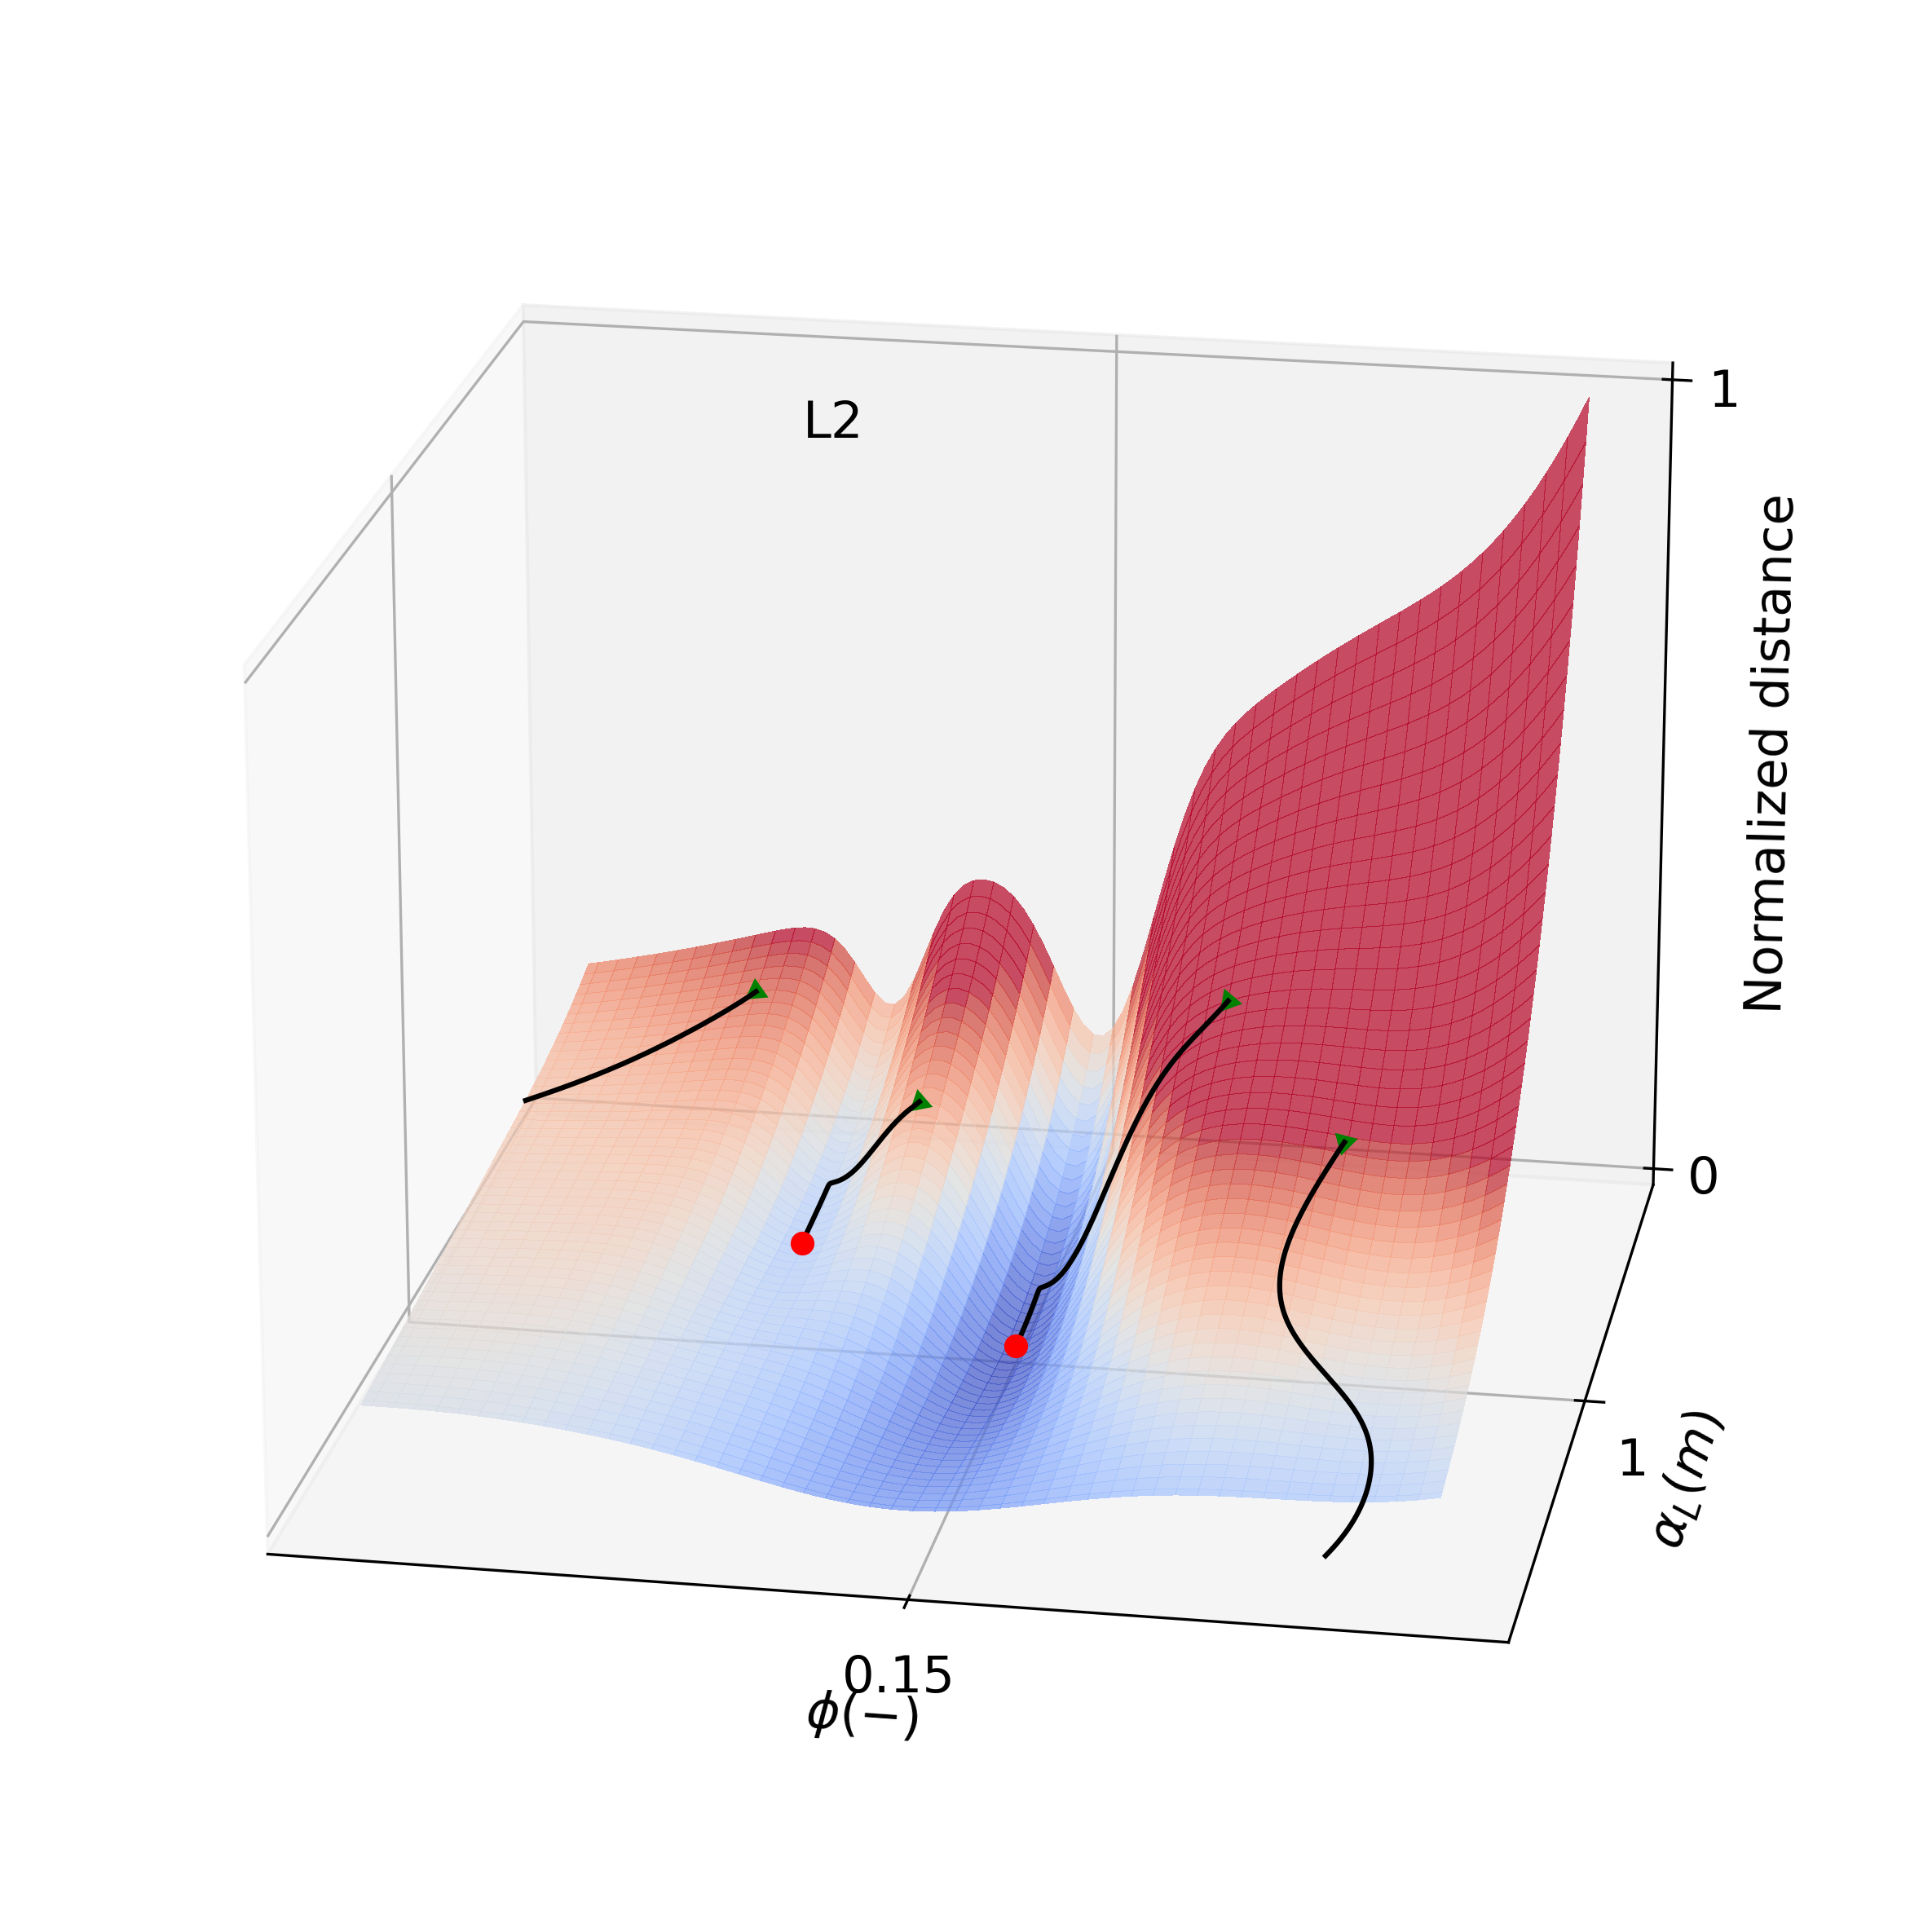

In [14]:
import matplotlib
font = {'size'   : 15}

matplotlib.rc('font', **font)

fig=plt.figure(dpi=300,figsize=(10,10))
ax = fig.add_subplot(projection='3d')


surf = ax.plot_surface(np.log10(x_phis),np.log10(y_alphas),Err_L2/np.max(Err_L2), cmap='coolwarm',alpha=.7,vmax=.27,
                      linewidth=.5, antialiased=False,zorder=1)
#plt.colorbar(surf,location='bottom')

plot_trajectories3d(20,20,Xs_L2_20_20,Err_L2_20_20/np.max(Err_L2),ax,in_bounds=False,mark=(3, 0,45))
plot_trajectories3d(60,30,Xs_L2_60_30,Err_L2_60_30/np.max(Err_L2),ax,mark=(3, 0,11))
plot_trajectories3d(30,30,Xs_L2_30_30,Err_L2_30_30/np.max(Err_L2),ax,mark=(3, 0,20))
plot_trajectories3d(80,10,Xs_L2_80_10,Err_L2_80_10/np.max(Err_L2),ax,in_bounds=False,mark=(3, 0,5))

ax.text(np.log10(.3),-1,.9,'L2')

xticks = [.15]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xticks)

yticks = [1]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels(yticks)

zticks = [0,1]
ax.set_zticks(zticks)




plt.ylabel(r'$\alpha_L (m)$')
ax.set_zlabel('Normalized distance')
plt.xlabel(r'$\phi (-)$')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#plt.legend(by_label.values(), by_label.keys())

ax.view_init(20,100)


#plt.savefig('Figures/04_L2.png',dpi=300)

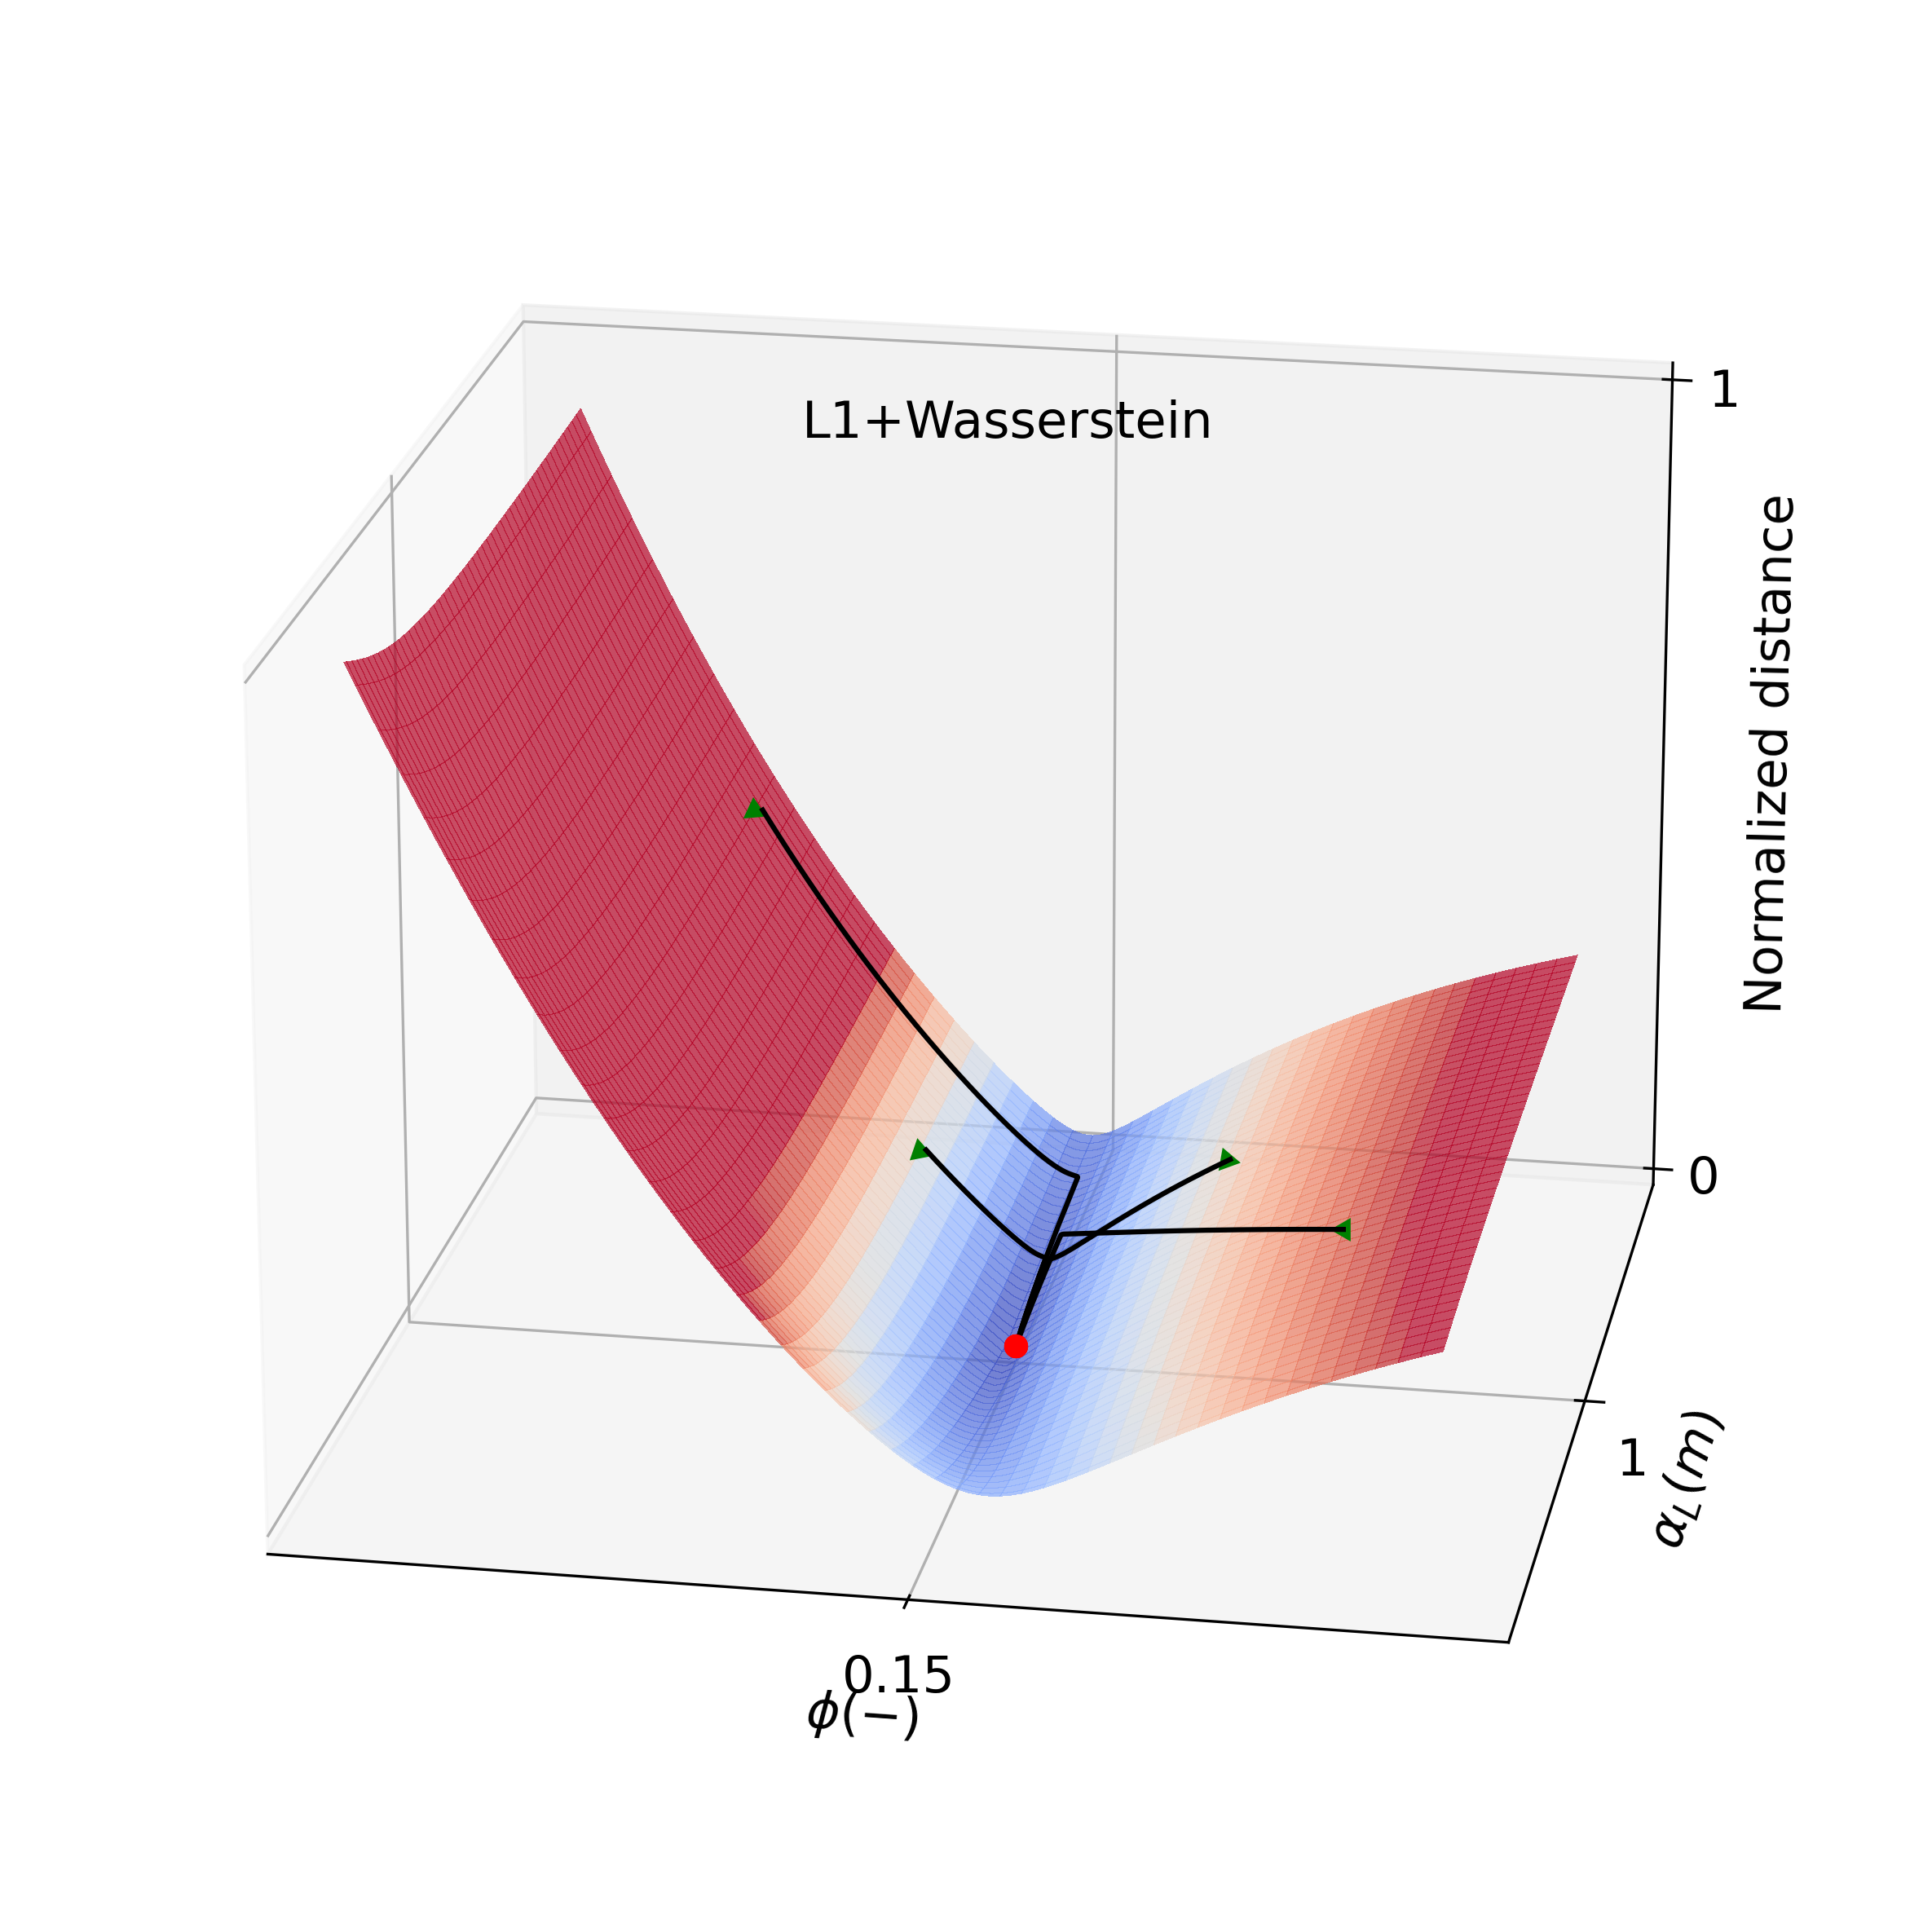

In [15]:
ax = plt.figure(figsize=(10,10),dpi=300).add_subplot(projection='3d')


surf = ax.plot_surface(np.log10(x_phis),np.log10(y_alphas),Err_Ot_W/np.max(Err_Ot_W), cmap='coolwarm',alpha=.7,vmax=.27,
                      linewidth=.5, antialiased=False,zorder=1)

plot_trajectories3d(20,20,Xs_W_20_20,Err_W_20_20/np.max(Err_Ot_W),ax,mark=(3, 0,90))
plot_trajectories3d(60,30,Xs_W_60_30,Err_W_60_30[:-1]/np.max(Err_Ot_W),ax,mark=(3, 0,11))
plot_trajectories3d(30,30,Xs_W_30_30,Err_W_30_30[:-1]/np.max(Err_Ot_W),ax,mark=(3, 0,20))
plot_trajectories3d(80,10,Xs_W_80_10,Err_W_80_10[:-1]/np.max(Err_Ot_W),ax,mark=(3, 0,5))

xticks = [.15]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xticks)

yticks = [1]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels(yticks)

zticks = [0,1]
ax.set_zticks(zticks)
plt.ylabel(r'$\alpha_L (m)$')
ax.set_zlabel('Normalized distance')
plt.xlabel(r'$\phi (-)$')

ax.text(np.log10(.3),-1,.9,'L1+Wasserstein')

ax.view_init(20,100)
#plt.savefig('Figures/05_W.png',dpi=300)

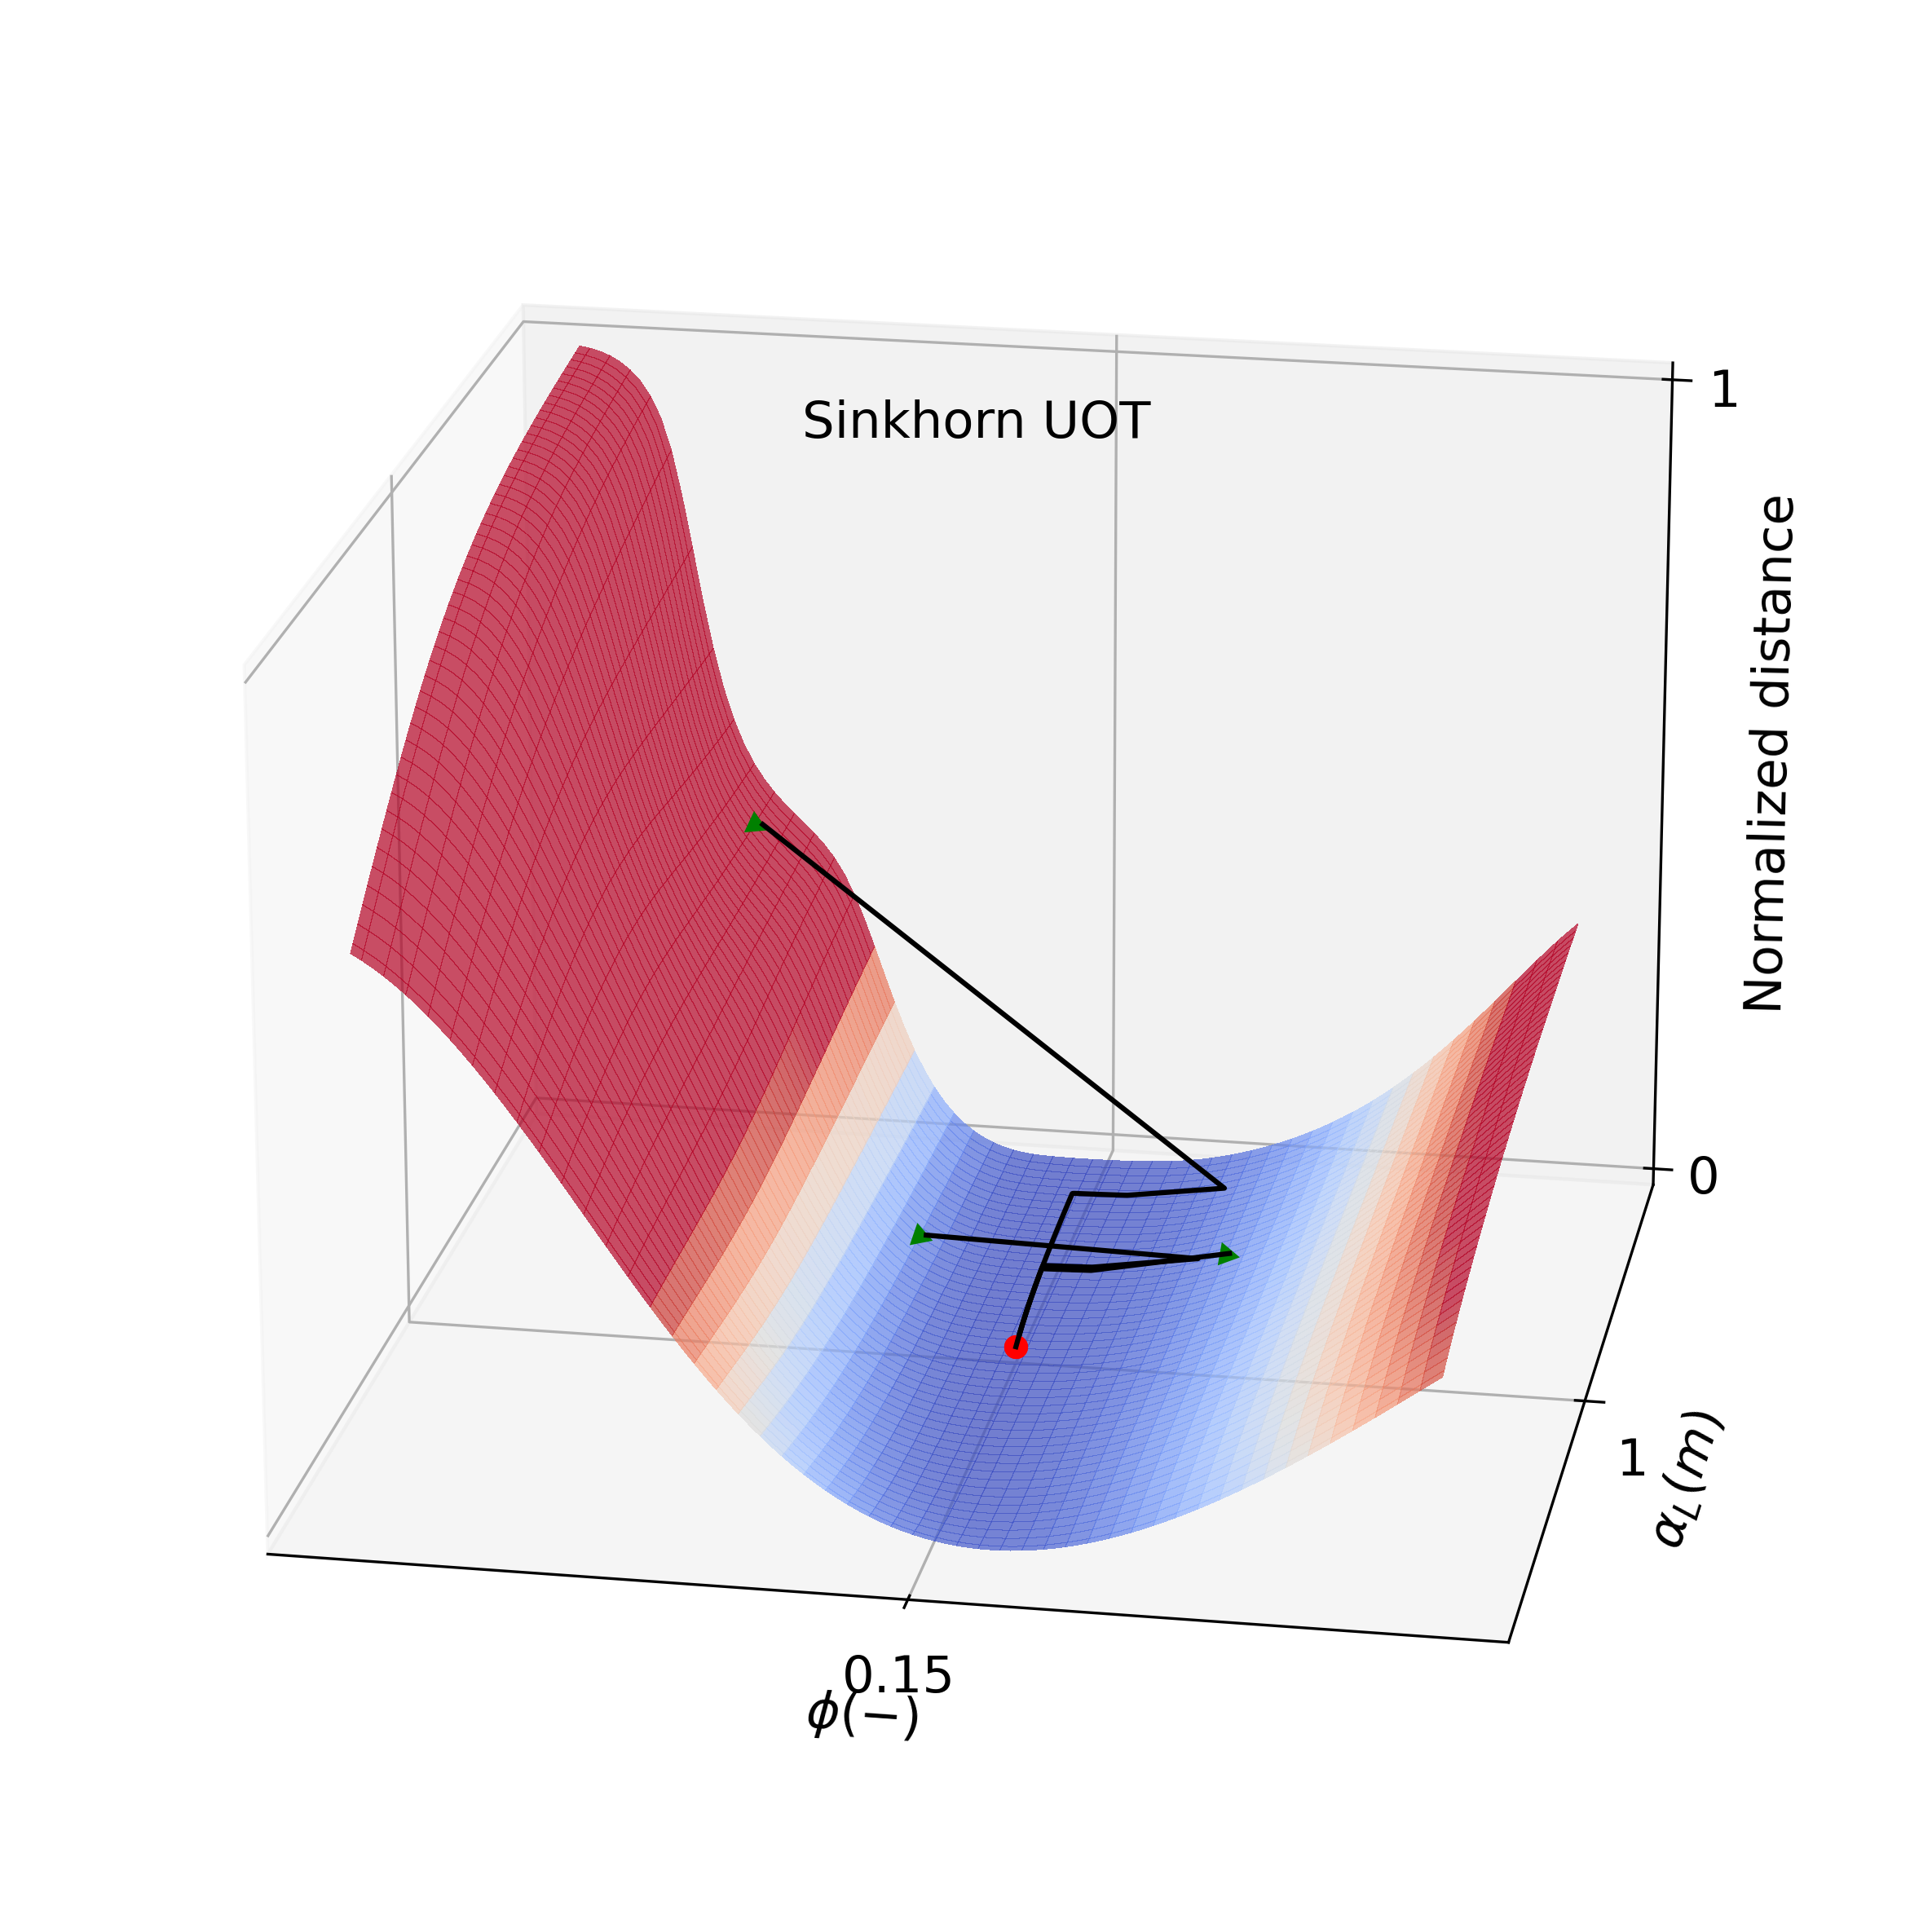

In [16]:
ax = plt.figure(figsize=(10,10),dpi=300).add_subplot(projection='3d')


surf = ax.plot_surface(np.log10(x_phis),np.log10(y_alphas),Err_Ot_S5/np.max(Err_Ot_S5), cmap='coolwarm',alpha=.7,vmax=.27,
                      linewidth=.5, antialiased=False,zorder=1)

#plot_trajectories3d(20,20,Xs_S_20_20,Err_S_20_20/np.max(Err_Ot_S5),ax,in_bounds=False,mark=(3, 0,45))
plot_trajectories3d(60,30,Xs_S_60_30,Err_S_60_30/np.max(Err_Ot_S5),ax,mark=(3, 0,11))
plot_trajectories3d(30,30,Xs_S_30_30,Err_S_30_30/np.max(Err_Ot_S5),ax,mark=(3, 0,20))
plot_trajectories3d(80,10,Xs_S_80_10,Err_S_80_10/np.max(Err_Ot_S5),ax,in_bounds=False,mark=(3, 0,5))

xticks = [.15]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xticks)

yticks = [1]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels(yticks)

zticks = [0,1]
ax.set_zticks(zticks)
plt.ylabel(r'$\alpha_L (m)$')
ax.set_zlabel('Normalized distance')
plt.xlabel(r'$\phi (-)$')

ax.text(np.log10(.3),-1,.9,'Sinkhorn UOT')

ax.view_init(20,100)
#plt.savefig('Figures/06_S.png',dpi=300)

### Final figure

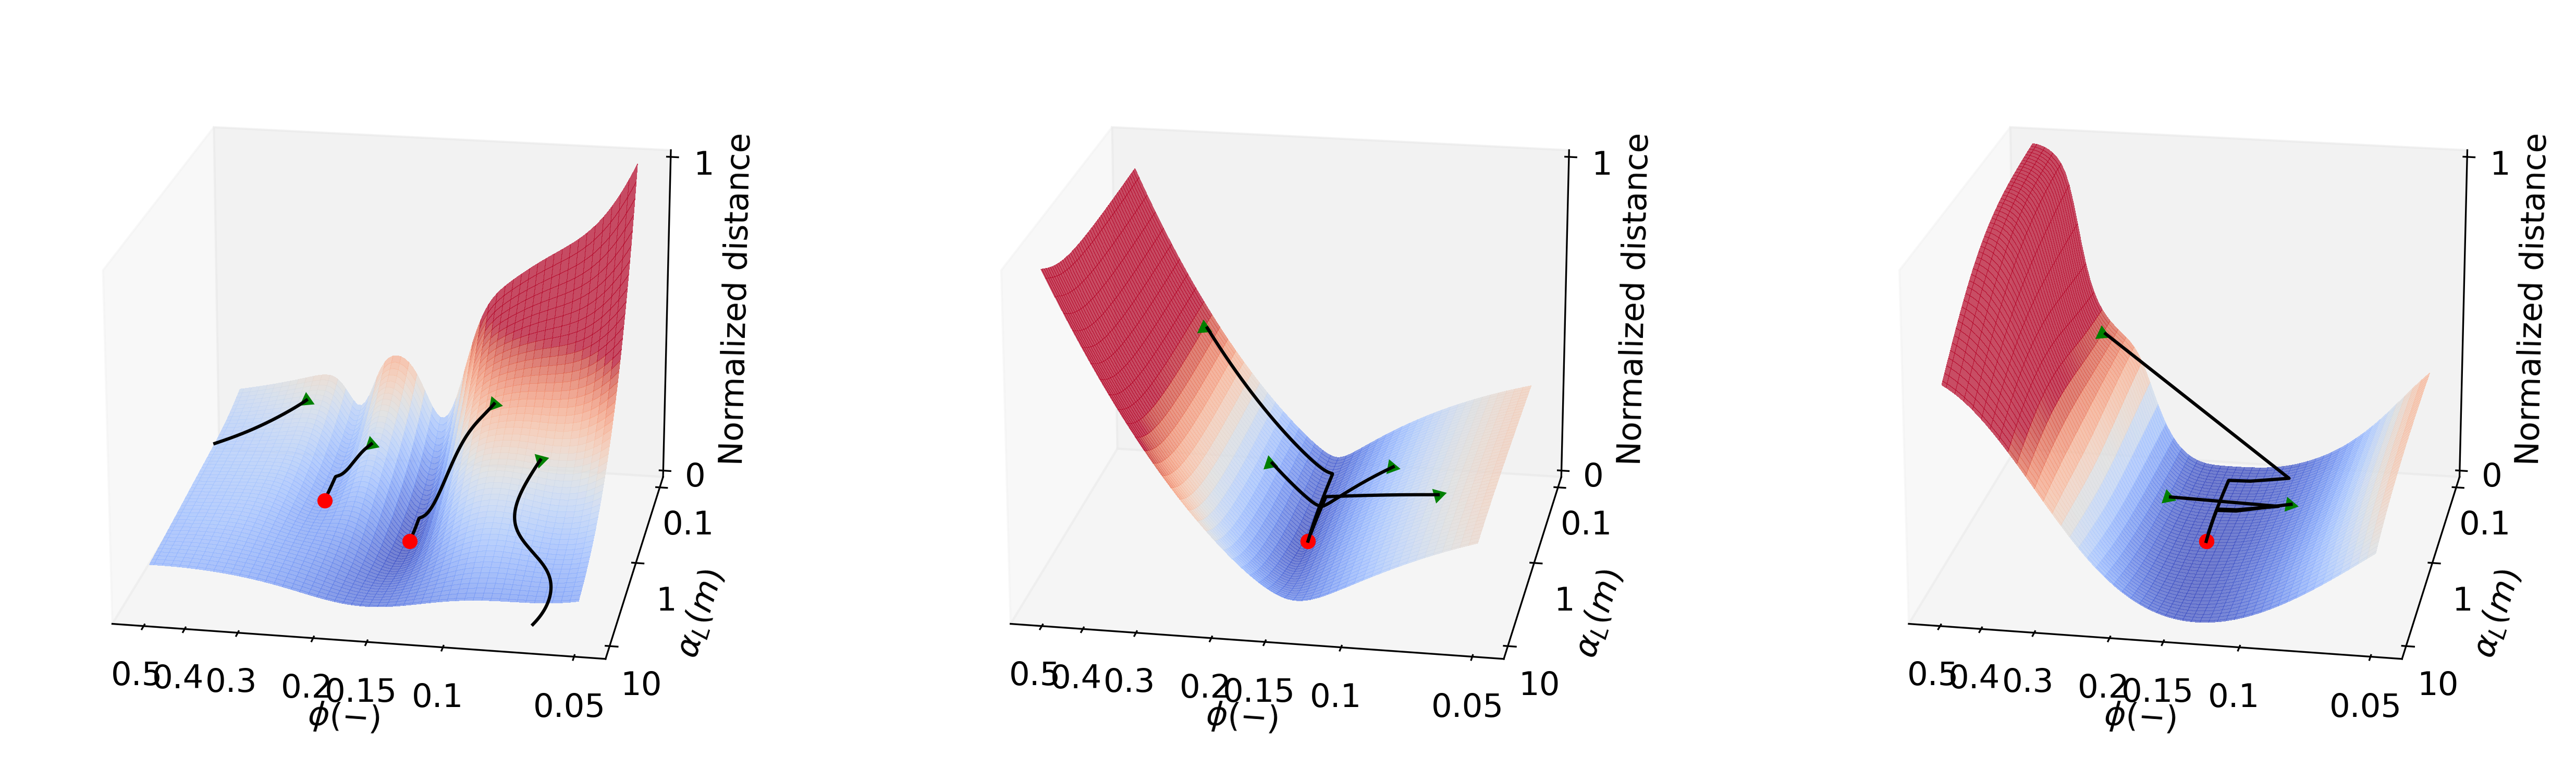

In [17]:
fig = plt.figure(figsize=(21,7),dpi=300)

ax = fig.add_subplot(1, 3, 1, projection='3d')

surf = ax.plot_surface(np.log10(x_phis),np.log10(y_alphas),Err_L2/np.max(Err_L2), cmap='coolwarm',alpha=.7,vmax=.5,
                      linewidth=.5, antialiased=False,zorder=1)
#plt.colorbar(surf,location='bottom')

plot_trajectories3d(20,20,Xs_L2_20_20,Err_L2_20_20/np.max(Err_L2),ax,in_bounds=False,mark=(3, 0,45))
plot_trajectories3d(60,30,Xs_L2_60_30,Err_L2_60_30/np.max(Err_L2),ax,mark=(3, 0,11))
plot_trajectories3d(30,30,Xs_L2_30_30,Err_L2_30_30/np.max(Err_L2),ax,mark=(3, 0,20))
plot_trajectories3d(80,10,Xs_L2_80_10,Err_L2_80_10/np.max(Err_L2),ax,in_bounds=False,mark=(3, 0,5))


xticks = [.05,.1,.15,.2,.3,.4,.5]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xticks)

yticks = [.1,1,10]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels(yticks)

zticks = [0,1]
ax.set_zticks(zticks)



plt.ylabel(r'$\alpha_L (m)$')
ax.set_zlabel('Normalized distance')
plt.xlabel(r'$\phi (-)$')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#plt.legend(by_label.values(), by_label.keys())

ax.view_init(20,100)
ax.grid(False)

ax = fig.add_subplot(1, 3, 2, projection='3d')

surf = ax.plot_surface(np.log10(x_phis),np.log10(y_alphas),Err_Ot_W/np.max(Err_Ot_W), cmap='coolwarm',alpha=.7,vmax=.5,
                      linewidth=.5, antialiased=False,zorder=1)

plot_trajectories3d(20,20,Xs_W_20_20,Err_W_20_20/np.max(Err_Ot_W),ax,in_bounds=False,mark=(3, 0,45))
plot_trajectories3d(60,30,Xs_W_60_30,Err_W_60_30[:-1]/np.max(Err_Ot_W),ax,mark=(3, 0,11))
plot_trajectories3d(30,30,Xs_W_30_30,Err_W_30_30[:-1]/np.max(Err_Ot_W),ax,mark=(3, 0,20))
plot_trajectories3d(80,10,Xs_W_80_10,Err_W_80_10[:-1]/np.max(Err_Ot_W),ax,in_bounds=False,mark=(3, 0,5))

xticks = [.05,.1,.15,.2,.3,.4,.5]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xticks)

yticks = [.1,1,10]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels(yticks)

zticks = [0,1]
ax.set_zticks(zticks)



plt.ylabel(r'$\alpha_L (m)$')
ax.set_zlabel('Normalized distance')
plt.xlabel(r'$\phi (-)$')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#plt.legend(by_label.values(), by_label.keys())

ax.view_init(20,100)
ax.grid(False)


ax = fig.add_subplot(1, 3, 3, projection='3d')

surf = ax.plot_surface(np.log10(x_phis),np.log10(y_alphas),Err_Ot_S5/np.max(Err_Ot_S5), cmap='coolwarm',alpha=.7,vmax=.5,
                      linewidth=.5, antialiased=False,zorder=1)

#plot_trajectories3d(20,20,Xs_S_20_20,Err_S_20_20/np.max(Err_Ot_S5),ax,in_bounds=False,mark=(3, 0,45))
plot_trajectories3d(60,30,Xs_S_60_30,Err_S_60_30/np.max(Err_Ot_S5),ax,mark=(3, 0,11))
plot_trajectories3d(30,30,Xs_S_30_30,Err_S_30_30/np.max(Err_Ot_S5),ax,mark=(3, 0,20))
plot_trajectories3d(80,10,Xs_S_80_10,Err_S_80_10/np.max(Err_Ot_S5),ax,in_bounds=False,mark=(3, 0,5))

xticks = [.05,.1,.15,.2,.3,.4,.5]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xticks)

yticks = [.1,1,10]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels(yticks)

zticks = [0,1]
ax.set_zticks(zticks)



plt.ylabel(r'$\alpha_L (m)$')
ax.set_zlabel('Normalized distance')
plt.xlabel(r'$\phi (-)$')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#plt.legend(by_label.values(), by_label.keys())

ax.view_init(20,100)
ax.grid(False)


#plt.savefig('Figures/gradient.png',dpi=300)

## Exemples

In [18]:
seconds_in_day=3600*24
times=np.linspace(100,seconds_in_day*300,1000)

test=multipeaks(times,[0,20*seconds_in_day],alpha=1,R=220,Q=10000/1000/60,Phi=0.15,L=20,M=1,rho=1000)
test2=multipeaks(times,[0,20*seconds_in_day],alpha=1,R=220,Q=10000/1000/60,Phi=0.245,L=20,M=1,rho=1000)
test3=multipeaks(times,[0,20*seconds_in_day],alpha=1,R=220,Q=10000/1000/60,Phi=0.065,L=20,M=1,rho=1000)
test4=multipeaks(times,[0,20*seconds_in_day],alpha=5,R=220,Q=10000/1000/60,Phi=0.15,L=20,M=1,rho=1000)

(0.0, 0.4)

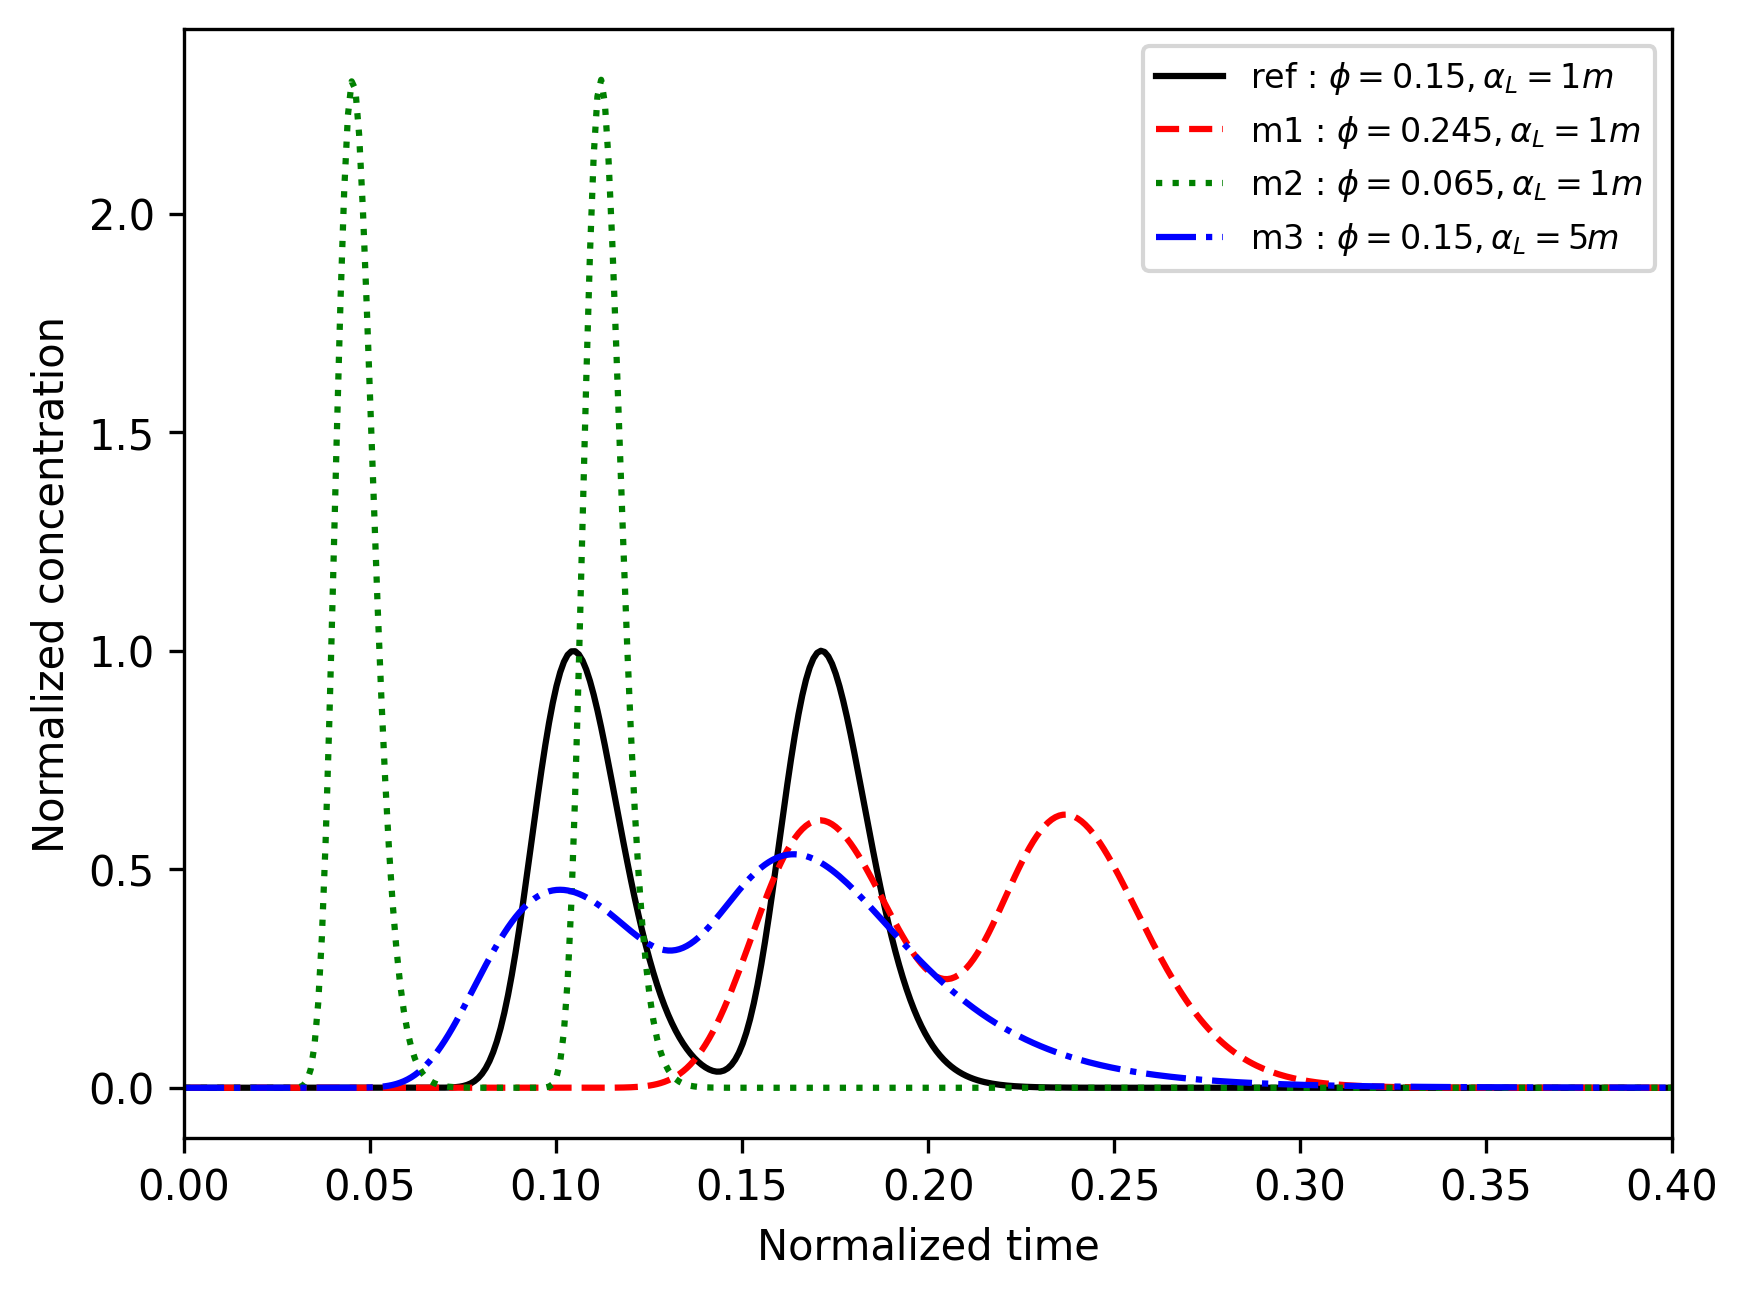

In [19]:

font = {'size'   : 10}

matplotlib.rc('font', **font)

plt.figure(dpi=300)
plt.plot(times/np.max(times),test/np.max(test),c='black',label=r'ref : $\phi=0.15 , \alpha_L=1m$')
plt.plot(times/np.max(times),test2/np.max(test),c='red',label=r'm1 : $\phi=0.245 , \alpha_L=1m$',linestyle='dashed')
plt.plot(times/np.max(times),test3/np.max(test),c='green',label=r'm2 : $\phi=0.065 , \alpha_L=1m$',linestyle='dotted')
plt.plot(times/np.max(times),test4/np.max(test),c='blue',label=r'm3 : $\phi=0.15 , \alpha_L=5m$',linestyle='dashdot')
plt.legend(fontsize=8)
plt.xlabel('Normalized time')
plt.ylabel('Normalized concentration')
plt.grid(False)
plt.xlim(0,0.4)
#plt.savefig('Figures/01_Examples.png',dpi=300)

## Cross sections

The following figures show cross sections of the objective functions

In [20]:
def plot_min_0(x):
    return x/np.nanmax(x)-np.nanmin(x/np.nanmax(x))

In [21]:
c_a_L2=np.loadtxt('arrays_gradient/caL2')
c_p_L2=np.loadtxt('arrays_gradient/cpL2')

c_a_W=np.loadtxt('arrays_gradient/caW')
c_p_W=np.loadtxt('arrays_gradient/cpW')

c_a_S4=np.loadtxt('arrays_gradient/caS4')
c_p_S4=np.loadtxt('arrays_gradient/cpS4')

c_a_S5=np.loadtxt('arrays_gradient/caS5')
c_p_S5=np.loadtxt('arrays_gradient/cpS5')

c_a_S6=np.loadtxt('arrays_gradient/caS6')
c_p_S6=np.loadtxt('arrays_gradient/cpS6')

In [22]:
def plot_min_0(x):
    return x/np.nanmax(x)-np.nanmin(x/np.nanmax(x))

[]

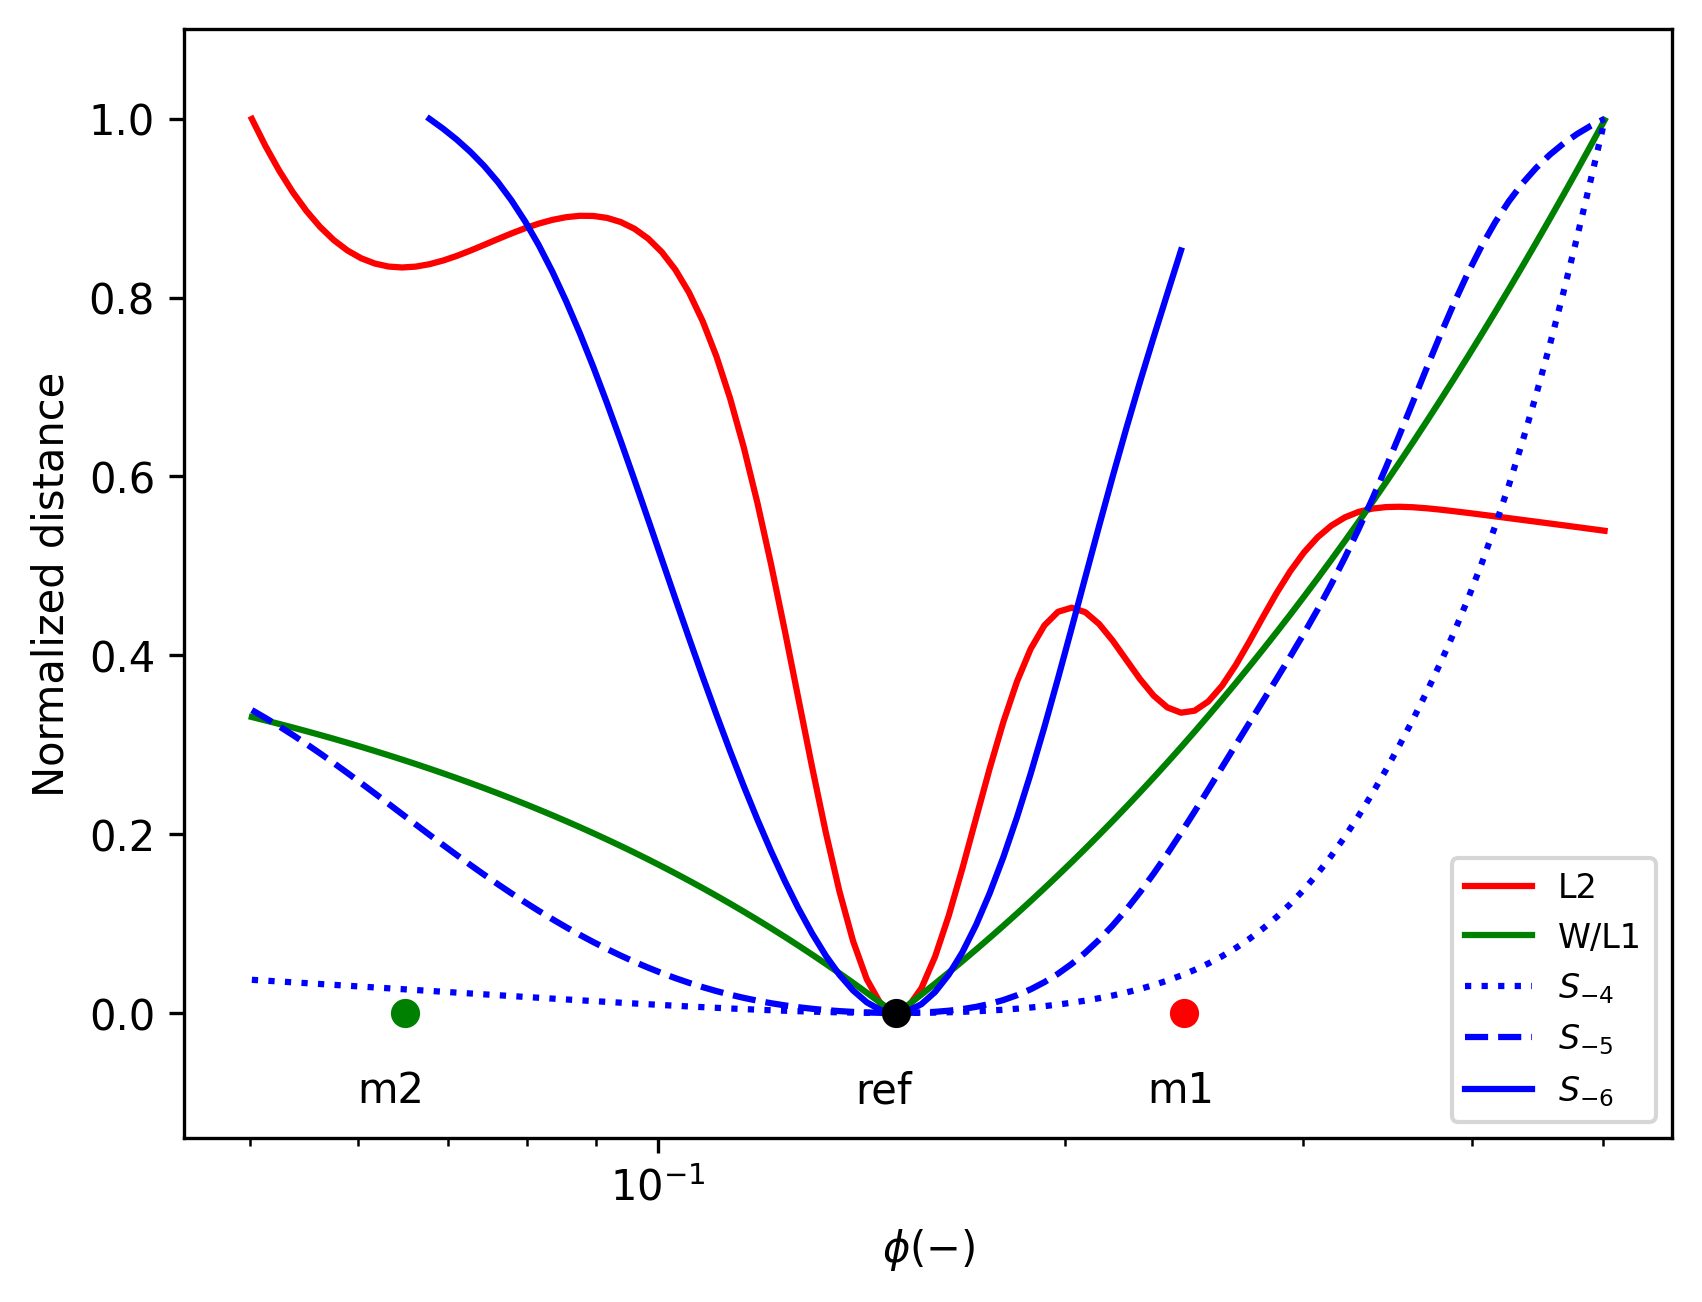

In [23]:

font = {'size'   : 10}

matplotlib.rc('font', **font)

phis=10**(np.linspace(0,1,100)-1.3)

plt.figure(dpi=300)

plt.plot(phis,plot_min_0(c_p_L2),label='L2',color='red')
plt.plot(phis,plot_min_0(c_p_W),label='W/L1',color='green')
plt.plot(phis,plot_min_0(c_p_S4),label=r'$S_{-4}$',color='blue',linestyle='dotted')
plt.plot(phis,plot_min_0(c_p_S5),label=r'$S_{-5}$',color='blue',linestyle='dashed')
plt.plot(phis,plot_min_0(c_p_S6),label=r'$S_{-6}$',color='blue')


plt.xlabel(r'$\phi (-)$')
plt.ylabel('Normalized distance')

plt.plot(0.15,0,'o',color='black')
plt.text(0.14,-0.1,'ref')

plt.plot(0.245,0,'o',color='red')
plt.text(0.23,-0.1,'m1')

plt.plot(0.065,0,'o',color='green')
plt.text(0.06,-0.1,'m2')


plt.ylim(-0.14,1.1)

plt.grid(False)

plt.legend(fontsize=8)
plt.semilogx()

#plt.savefig('Figures/02_cross_section_phi.png',dpi=300)

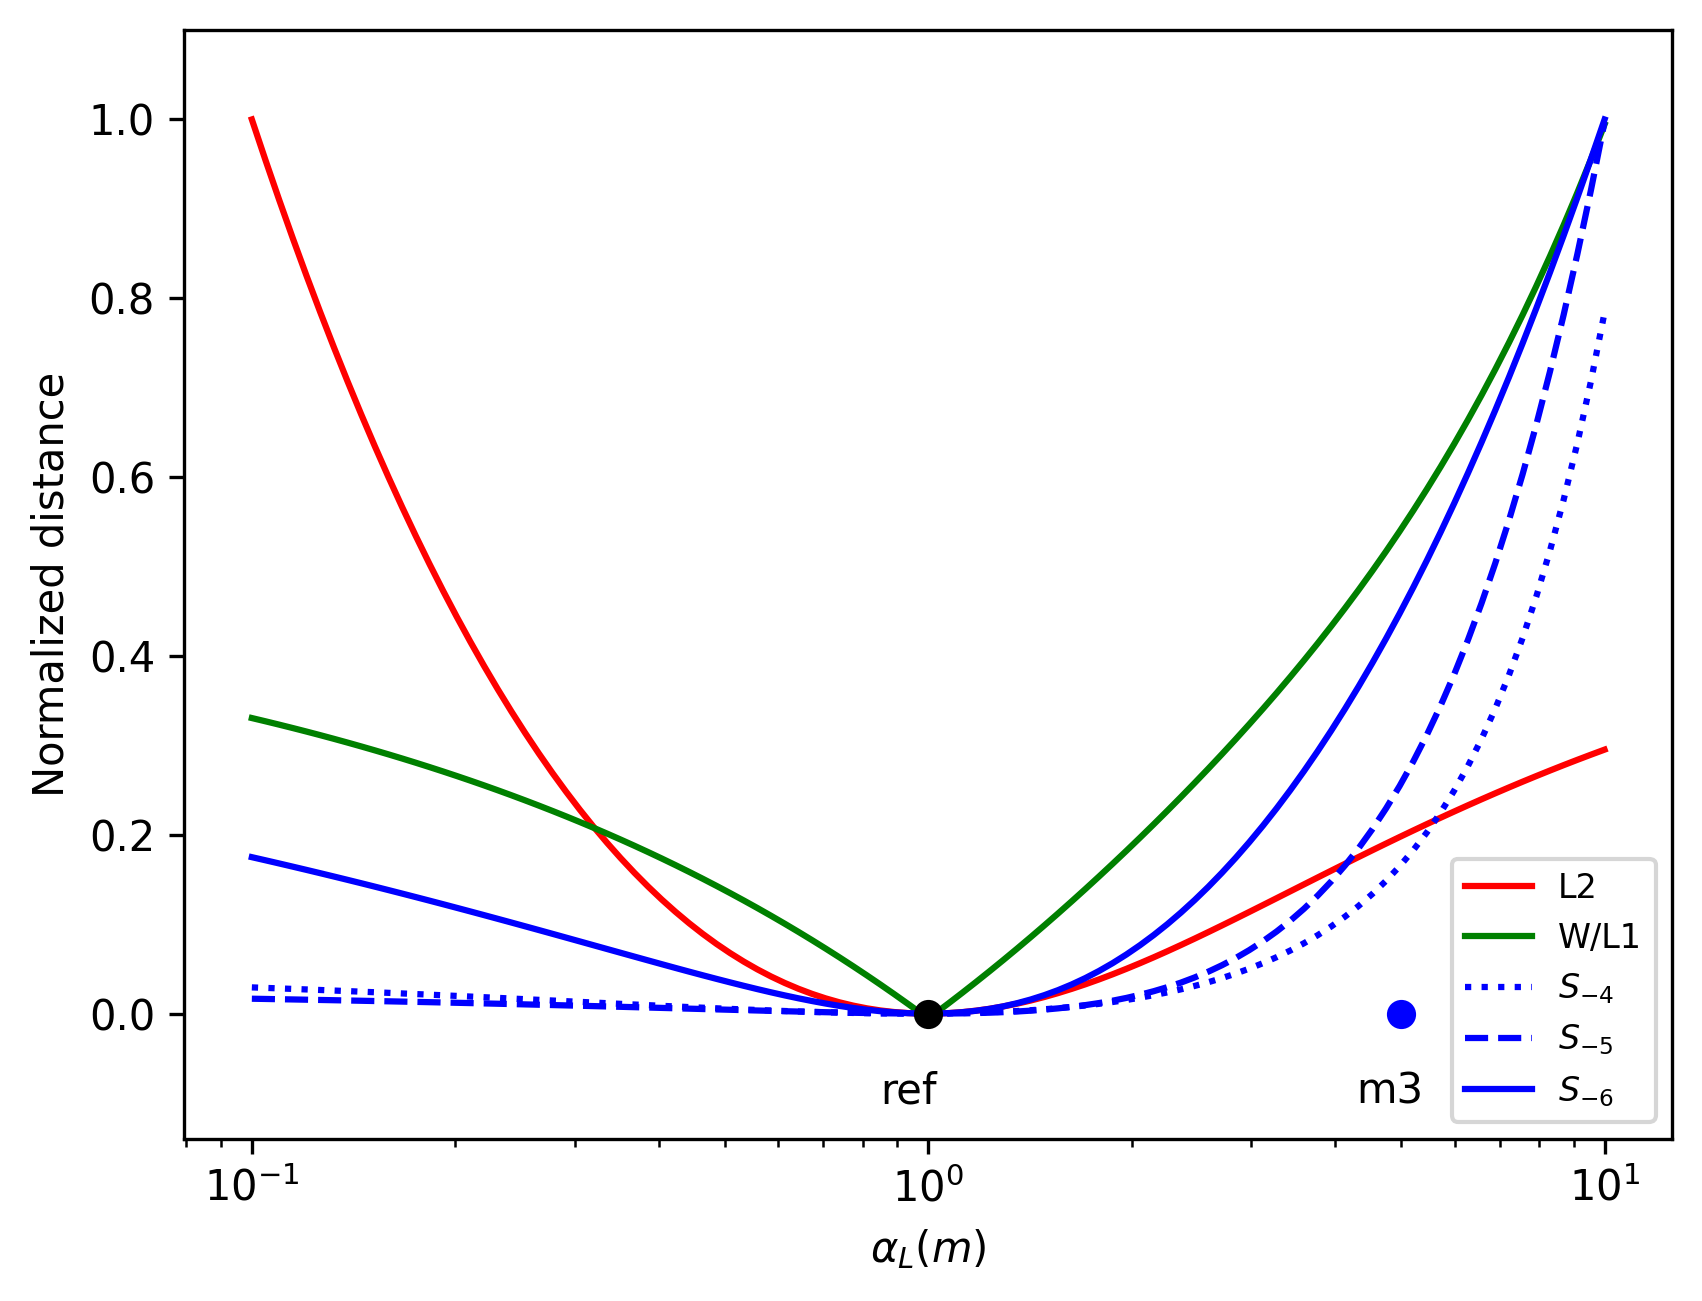

In [24]:
alphas=10**(np.linspace(0,1,100)*2-1)

plt.figure(dpi=300)

plt.plot(alphas,plot_min_0(c_a_L2),label='L2',color='red')
plt.plot(alphas,plot_min_0(c_a_W),label='W/L1',color='green')
plt.plot(alphas,plot_min_0(c_a_S4),label=r'$S_{-4}$',color='blue',linestyle='dotted')
plt.plot(alphas,plot_min_0(c_a_S5),label=r'$S_{-5}$',color='blue',linestyle='dashed')
plt.plot(alphas,plot_min_0(c_a_S6),label=r'$S_{-6}$',color='blue')
plt.semilogx()

plt.xlabel(r'$\alpha_L (m)$')
plt.ylabel('Normalized distance')

plt.plot(1,0,'o',color='black')
plt.text(0.85,-0.1,'ref')

plt.plot(5,0,'o',color='blue')
plt.text(4.3,-0.1,'m3')



plt.ylim(-0.14,1.1)
plt.grid(False)
plt.legend(fontsize=8)
#plt.savefig('Figures/03_cross_section_alpha.png',dpi=300)

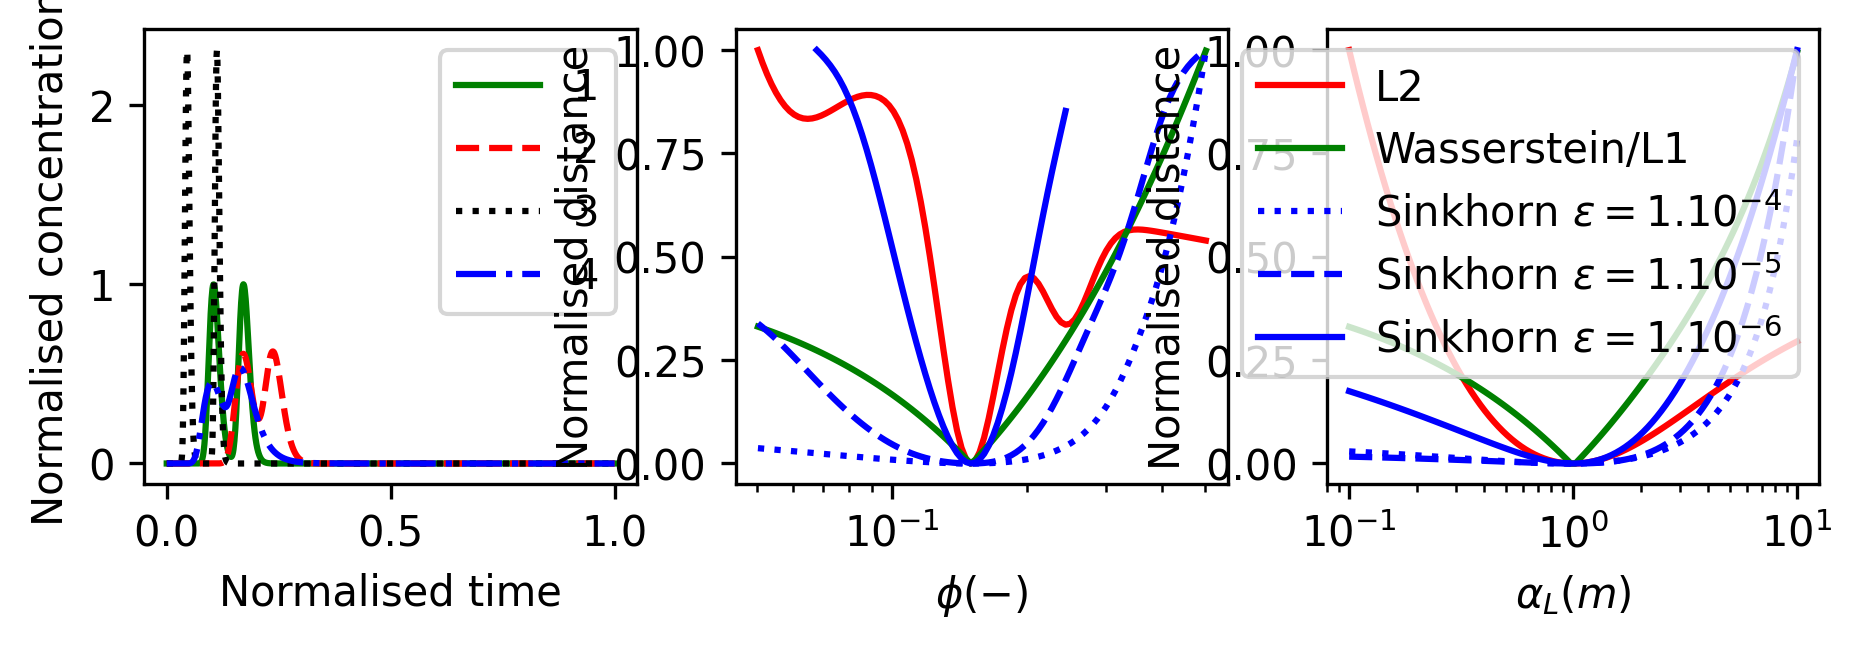

In [25]:
cm_to_inch=0.393701

plt.subplots(1,3,dpi=300,figsize=(18.3*cm_to_inch,5*cm_to_inch))

plt.subplot(131)
plt.plot(times/np.max(times),test/np.max(test),c='green',label='1')
plt.plot(times/np.max(times),test2/np.max(test),c='red',label='2',linestyle='dashed')
plt.plot(times/np.max(times),test3/np.max(test),c='black',label='3',linestyle='dotted')
plt.plot(times/np.max(times),test4/np.max(test),c='blue',label='4',linestyle='dashdot')
plt.legend()
plt.xlabel('Normalised time')
plt.ylabel('Normalised concentration')

plt.subplot(132)

plt.plot(phis,plot_min_0(c_p_L2),label='L2',color='red')
plt.plot(phis,plot_min_0(c_p_W),label='Wasserstein/L1',color='green')
plt.plot(phis,plot_min_0(c_p_S4),label=r'Sinkhorn $\epsilon = 1.10^{-4}$',color='blue',linestyle='dotted')
plt.plot(phis,plot_min_0(c_p_S5),label=r'Sinkhorn $\epsilon = 1.10^{-5}$',color='blue',linestyle='dashed')
plt.plot(phis,plot_min_0(c_p_S6),label=r'Sinkhorn $\epsilon = 1.10^{-6}$',color='blue')


plt.xlabel(r'$\phi (-)$')
plt.ylabel('Normalised distance')
plt.semilogx()

plt.subplot(133)

plt.plot(alphas,plot_min_0(c_a_L2),label='L2',color='red')
plt.plot(alphas,plot_min_0(c_a_W),label='Wasserstein/L1',color='green')
plt.plot(alphas,plot_min_0(c_a_S4),label=r'Sinkhorn $\epsilon = 1.10^{-4}$',color='blue',linestyle='dotted')
plt.plot(alphas,plot_min_0(c_a_S5),label=r'Sinkhorn $\epsilon = 1.10^{-5}$',color='blue',linestyle='dashed')
plt.plot(alphas,plot_min_0(c_a_S6),label=r'Sinkhorn $\epsilon = 1.10^{-6}$',color='blue')
plt.semilogx()

plt.xlabel(r'$\alpha_L (m)$')
plt.ylabel('Normalised distance')

plt.legend()

#plt.savefig('Figures/example_and_cross_sections.png',dpi=300)